# 🚚 Last Mile Delivery Delay Root Cause Analysis

Professional end-to-end analytics notebook.

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
plt.style.use("ggplot")

## Load Dataset

In [3]:
df=pd.read_csv("last_mile_delivery_dataset.csv")
print(df.shape)
display(df.head())
df.info()

(2080, 20)


,order_id,order_date,order_time,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,delivery_status,weather_condition,order_value_inr,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude
0,ORD000001,2024-09-02,13:10,Chennai,East,RID0022,Cycle,Electronics,11.05,60,57.4,-2.6,On-Time,Partly Cloudy,377.96,1,7.9,4.6,28.9867,87.3825
1,ORD000002,2024-09-13,14:53,Delhi,East,RID0100,cycle,Electronics,14.75,30,29.7,-0.3,On-Time,Clear,1352.80,1,0.4,4.5,36.7618,84.6386
2,ORD000003,2024-02-28,18:01,Lucknow,NaN,RID0010,Bike,Documents,11.21,60,87.0,27.0,Delayed,Clear,1302.15,2,7.8,3.4,NaN,NaN
3,ORD000004,2024-07-13,14:59,Chennai,North,RID0050,AUTO,Documents,10.27,30,57.2,27.2,Delayed,Rain,3308.73,1,6.8,4.4,17.7429,71.3316
4,ORD000005,2024-07-24,14:28,Jaipur,South,RID0078,Bike,Apparel,13.07,60,55.5,-4.5,On-Time,Partly Cloudy,3095.74,2,1.1,3.1,22.9501,96.4950


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                2080 non-null   object 
 1   order_date              2080 non-null   object 
 2   order_time              2080 non-null   object 
 3   city                    2080 non-null   object 
 4   zone                    1944 non-null   object 
 5   rider_id                1967 non-null   object 
 6   vehicle_type            2080 non-null   object 
 7   order_type              2080 non-null   object 
 8   distance_km             2080 non-null   float64
 9   promised_delivery_mins  2080 non-null   int64  
 10  actual_delivery_mins    2080 non-null   object 
 11  delay_mins              2080 non-null   float64
 12  delivery_status         2080 non-null   object 
 13  weather_condition       2080 non-null   object 
 14  order_value_inr         2080 non-null   

## Data Cleaning

In [4]:
print(df.isnull().sum())
print(df.duplicated().sum())
df=df.drop_duplicates()
df["order_time"]=pd.to_datetime(df["order_time"])
df["delay_mins"]=pd.to_numeric(df["delay_mins"],errors="coerce")
df=df.dropna()
print(df.shape)

order_id                    0
order_date                  0
order_time                  0
city                        0
zone                      136
rider_id                  113
vehicle_type                0
order_type                  0
distance_km                 0
promised_delivery_mins      0
actual_delivery_mins        0
delay_mins                  0
delivery_status             0
weather_condition           0
order_value_inr             0
delivery_attempts           0
rider_experience_yrs        0
rider_rating                0
gps_latitude              137
gps_longitude             137
dtype: int64
0
(1720, 20)


C:\Users\VISHWADEEP\AppData\Local\Temp\ipykernel_25088\973280851.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["order_time"]=pd.to_datetime(df["order_time"])


## Q1 Peak Hour Delay Pattern

,count,mean,median
Period,,,
Off-Peak,1191,9.346851,7.1
Peak,529,23.106238,20.5


12.454907373151793 3.7381650571200166e-34


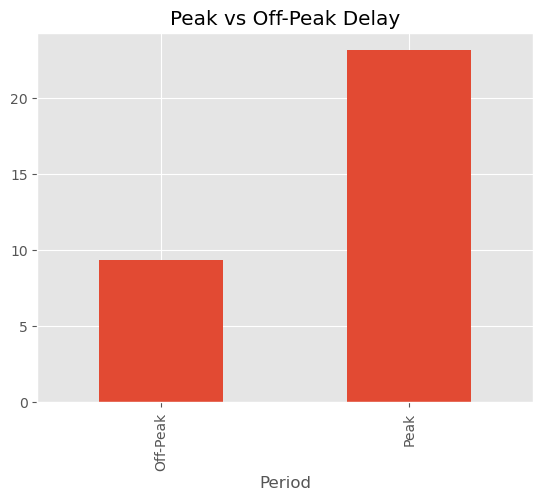

In [5]:
hour=df["order_time"].dt.hour
df["Period"]=np.where(((hour>=8)&(hour<10))|((hour>=17)&(hour<20)),"Peak","Off-Peak")
summary=df.groupby("Period")["delay_mins"].agg(["count","mean","median"])
display(summary)
peak=df[df["Period"]=="Peak"]["delay_mins"]
off=df[df["Period"]=="Off-Peak"]["delay_mins"]
t,p=ttest_ind(peak,off)
print(t,p)
summary["mean"].plot(kind="bar",title="Peak vs Off-Peak Delay")
plt.show()

Interpret the p-value to determine whether the difference is statistically significant.

## Q2 Weather Analysis

weather_condition
Clear             6.0
Fog              37.8
Partly Cloudy     5.5
Rain             29.2
Name: delay_mins, dtype: float64

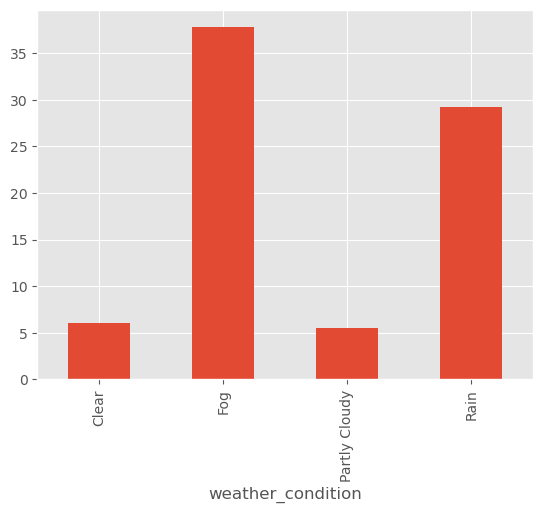

order_type
Medicine       36.60
Documents      31.80
Apparel        29.70
Electronics    28.80
Grocery        25.85
Food           22.75
Name: delay_mins, dtype: float64

In [6]:
weather=df.groupby("weather_condition")["delay_mins"].median()
display(weather)
weather.plot(kind="bar")
plt.show()

rain=df[df["weather_condition"]=="Rain"]
display(rain.groupby("order_type")["delay_mins"].median().sort_values(ascending=False))

## Q3 Rider Experience

In [7]:
less2=df[df["rider_experience_yrs"]<2]["delay_mins"]
more4=df[df["rider_experience_yrs"]>4]["delay_mins"]
t,p=ttest_ind(less2,more4)
print(t,p)

-1.0652541479248696 0.2869674799347265


## Q4 Dashboard

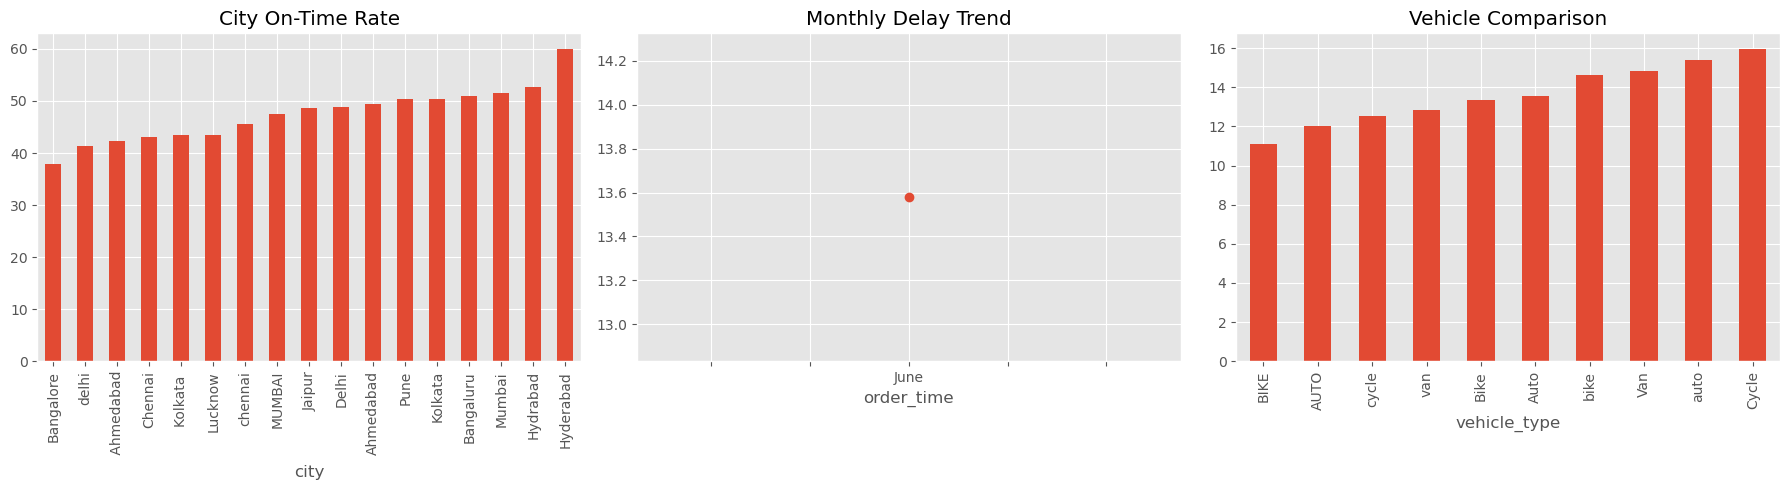

In [8]:
df["On_Time"]=np.where(df["delay_mins"]<=10,1,0)
city=df.groupby("city")["On_Time"].mean()*100
monthly=df.groupby(df["order_time"].dt.month_name())["delay_mins"].mean()
months=["January","February","March","April","May","June","July","August","September","October","November","December"]
monthly=monthly.reindex(months)
vehicle=df.groupby("vehicle_type")["delay_mins"].mean()
fig,ax=plt.subplots(1,3,figsize=(18,5))
city.sort_values().plot(kind="bar",ax=ax[0],title="City On-Time Rate")
monthly.plot(marker="o",ax=ax[1],title="Monthly Delay Trend")
vehicle.sort_values().plot(kind="bar",ax=ax[2],title="Vehicle Comparison")
plt.tight_layout()
plt.show()